In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [20]:
types = {'InvoiceNo': 'string', 'StockCode': 'string', 'CustomerID': 'string'}
df = pd.read_csv('../data/clean_all.csv', parse_dates=['InvoiceDate'], dtype=types)
sales = pd.read_csv('../data/sales.csv', parse_dates=['InvoiceDate'], dtype=types)
returns = pd.read_csv('../data/returns.csv', parse_dates=['InvoiceDate'], dtype=types)

print(sales.shape, returns.shape)


(522685, 18) (8670, 18)


## Q1. Which products generate the most units sold and the most revenue?

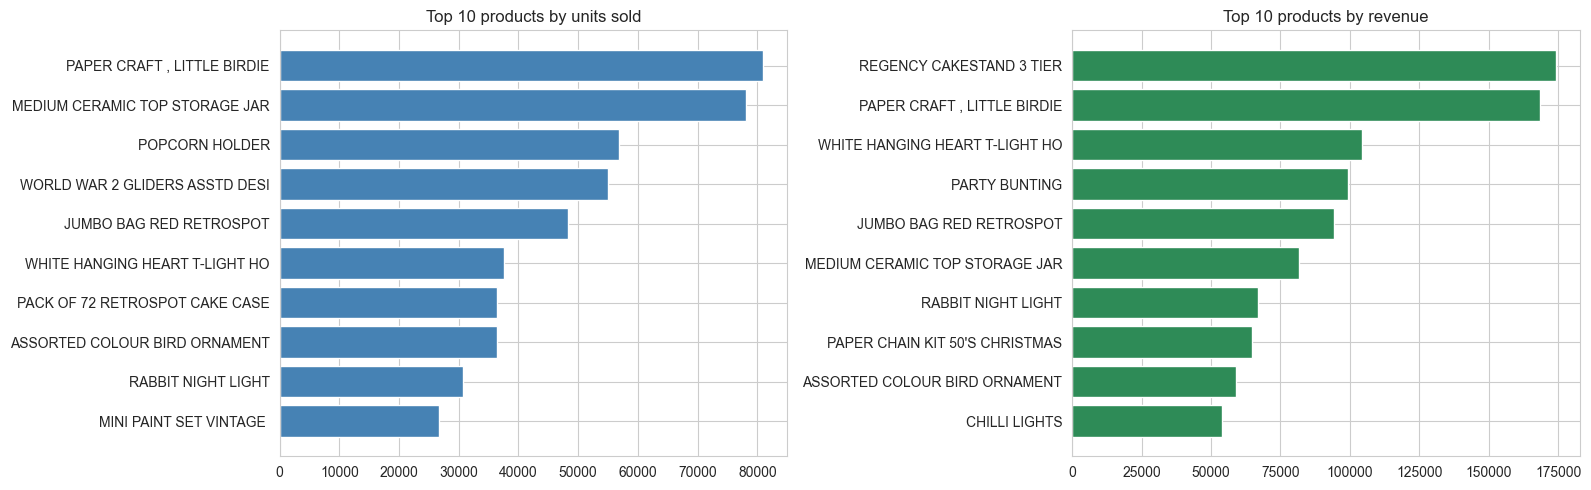

Top product by revenue: REGENCY CAKESTAND 3 TIER
Top product by units: PAPER CRAFT , LITTLE BIRDIE


In [21]:
prod = sales.groupby('StockCode').agg(
    Description=('Description', lambda x: x.dropna().mode().iloc[0] if x.notna().any() else ''),
    Units=('Quantity', 'sum'),
    Revenue=('TotalLineRevenue', 'sum')).sort_values('Revenue', ascending=False)

top_units = prod.sort_values('Units', ascending=False).head(10)
top_rev = prod.head(10)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].barh(top_units['Description'].str[:30][::-1], top_units['Units'][::-1], color='steelblue')
ax[0].set_title('Top 10 products by units sold')
ax[1].barh(top_rev['Description'].str[:30][::-1], top_rev['Revenue'][::-1], color='seagreen')
ax[1].set_title('Top 10 products by revenue')
plt.tight_layout()
plt.show()

top_prod_rev = top_rev.iloc[0]['Description']
top_prod_units = top_units.iloc[0]['Description']
print('Top product by revenue:', top_prod_rev)
print('Top product by units:', top_prod_units)

**Interpretation:** The top products by units are not always the top by revenue. Cheap items (small decorations, bags) sell in large numbers, while more expensive items bring more money with fewer units. I also need to be careful: if a product has an extremely high unit count, it may come from one giant order. I check this again in the returns section.

### Pareto: do 20% of products make 80% of revenue?

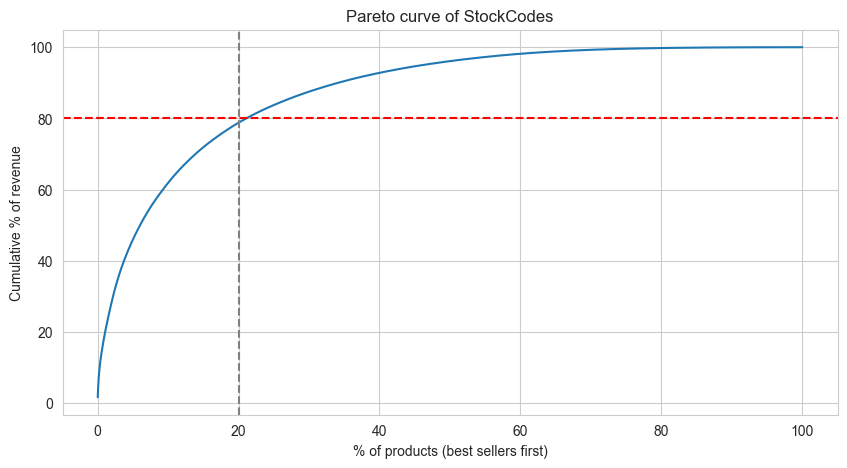

825 products (21.1% of all products) make 80% of the revenue
The top 20% of products make 78.8% of revenue


In [32]:
p = prod['Revenue'].sort_values(ascending=False)
cum = p.cumsum() / p.sum()
n80 = (cum <= 0.8).sum() + 1
pareto_pct = n80 / len(p) * 100

plt.plot(np.arange(1, len(p) + 1) / len(p) * 100, cum.values * 100)
plt.axhline(80, color='red', linestyle='--')
plt.axvline(20, color='grey', linestyle='--')
plt.xlabel('% of products (best sellers first)')
plt.ylabel('Cumulative % of revenue')
plt.title('Pareto curve of StockCodes')
plt.show()

print(f'{n80} products ({pareto_pct:.1f}% of all products) make 80% of the revenue')
print(f'The top 20% of products make {cum.iloc[int(len(p) * 0.2)] * 100:.1f}% of revenue')

**Interpretation:** Revenue is concentrated in a smaller part of the catalogue, so the Pareto idea holds roughly. The business should protect stock of these best sellers first.

### Dead stock: high volume in the past but nothing sold in the last 90 days

In [33]:
cutoff = df['InvoiceDate'].max() - pd.Timedelta(days=90)

before = sales[sales['InvoiceDate'] < cutoff].groupby('StockCode')['Quantity'].sum()
high_volume = before[before >= before.quantile(0.75)].index      # top 25% by past volume

# net units in the last 90 days (sales minus returns)
recent = pd.concat([sales, returns])
recent = recent[recent['InvoiceDate'] >= cutoff].groupby('StockCode')['Quantity'].sum()
recent = recent.reindex(high_volume).fillna(0)

dead = recent[recent <= 0].index
dead_count = len(dead)

dead_table = pd.DataFrame({'Description': prod.loc[dead, 'Description'],
                           'Units_before_cutoff': before.loc[dead]}).sort_values('Units_before_cutoff', ascending=False)
print('Cutoff date:', cutoff.date())
print('High volume products:', len(high_volume))
print('Of those, dead stock (<= 0 net sales in last 90 days):', dead_count)
dead_table.head(10)

Cutoff date: 2011-09-10
High volume products: 917
Of those, dead stock (<= 0 net sales in last 90 days): 21


,Description,Units_before_cutoff
StockCode,,
18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,5884
10133,COLOURING PENCILS BROWN TUBE,2856
22855,FINE WICKER HEART,2642
47556B,TEA TIME TEA TOWELS,2600
17096,ASSORTED LAQUERED INCENSE HOLDERS,2545
21399,BLUE POLKADOT COFFEE MUG,2054
21069,VINTAGE BILLBOARD TEA MUG,1949
21033,JUMBO BAG CHARLIE AND LOLA TOYS,1932
22088,PAPER BUNTING COLOURED LACE,1893


**Interpretation:** These products used to sell well but stopped. They could be seasonal items, discontinued items or products that need a clearance. The business should check each one before re-ordering.

## Q2. Which customers contribute the most revenue and orders?

In [22]:
known = sales[sales['CustomerID'].notna()]

cust = known.groupby('CustomerID').agg(
    Orders=('InvoiceNo', 'nunique'),
    Revenue=('TotalLineRevenue', 'sum'),
    Units=('Quantity', 'sum'),
    UniqueProducts=('StockCode', 'nunique'))
cust['AOV'] = cust['Revenue'] / cust['Orders']

print('Top 10 customers by revenue')
display(cust.sort_values('Revenue', ascending=False).head(10))
print('Top 10 customers by number of orders')
display(cust.sort_values('Orders', ascending=False).head(10))

top10pct_share = cust['Revenue'].sort_values(ascending=False).head(int(len(cust) * 0.1)).sum() / cust['Revenue'].sum()
print(f'Top 10% of customers make {top10pct_share * 100:.1f}% of the revenue from known customers')

Top 10 customers by revenue


,Orders,Revenue,Units,UniqueProducts,AOV
CustomerID,,,,,
14646,72,279138.02,196844,699,3876.916944
18102,60,259657.30,64124,150,4327.621667
17450,46,194390.79,69973,124,4225.886739
16446,2,168472.50,80997,3,84236.250000
14911,199,140336.83,80238,1786,705.210201
12415,20,124564.53,77373,443,6228.226500
14156,55,117210.08,57768,714,2131.092364
17511,31,91062.38,64549,453,2937.496129
12346,1,77183.60,74215,1,77183.600000


Top 10 customers by number of orders


,Orders,Revenue,Units,UniqueProducts,AOV
CustomerID,,,,,
12748,206,31650.78,25051,1766,153.644563
14911,199,140336.83,80238,1786,705.210201
17841,124,40495.99,22816,1322,326.580565
13089,97,58762.08,31025,636,605.794639
15311,91,60632.75,38147,567,666.293956
14606,90,11926.15,6177,816,132.512778
12971,86,11189.91,9289,94,130.115233
14646,72,279138.02,196844,699,3876.916944
13408,62,28117.04,16232,234,453.500645


Top 10% of customers make 61.4% of the revenue from known customers


**Interpretation:** A small number of customers bring a big part of the revenue. Losing one of the top customers would hurt much more than losing a normal one.

## Q3. How does revenue change over time?

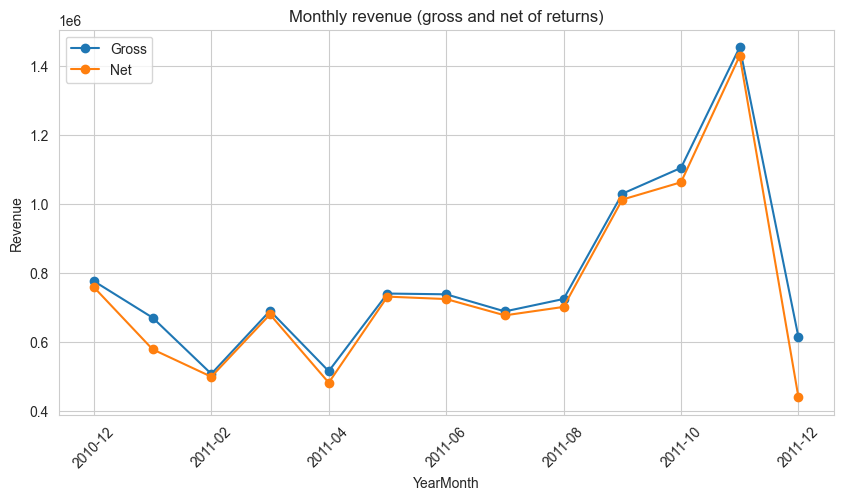

,Gross,Returns,Net
YearMonth,,,
2010-12,776315.0,-17548.0,758767.0
2011-01,670639.0,-91575.0,579064.0
2011-02,508065.0,-8336.0,499730.0
2011-03,690467.0,-10504.0,679963.0
2011-04,515863.0,-33316.0,482547.0
2011-05,740436.0,-8948.0,731488.0
2011-06,738234.0,-13729.0,724505.0
2011-07,688728.0,-11407.0,677321.0
2011-08,724688.0,-22927.0,701762.0


In [23]:
monthly_gross = sales.groupby('YearMonth')['TotalLineRevenue'].sum()
monthly_ret = returns.groupby('YearMonth')['TotalLineRevenue'].sum()
monthly = pd.DataFrame({'Gross': monthly_gross, 'Returns': monthly_ret}).fillna(0)
monthly['Net'] = monthly['Gross'] + monthly['Returns']

monthly[['Gross', 'Net']].plot(marker='o')
plt.title('Monthly revenue (gross and net of returns)')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()
monthly.round(0)

**Interpretation:** Revenue goes up strongly towards the end of the year (September to November). The last point (December 2011) is low only because the data ends on 9 December, it is not a real drop. The gap between gross and net line is the money lost to returns.

## Q4. Which months, weekdays and hours are strongest?

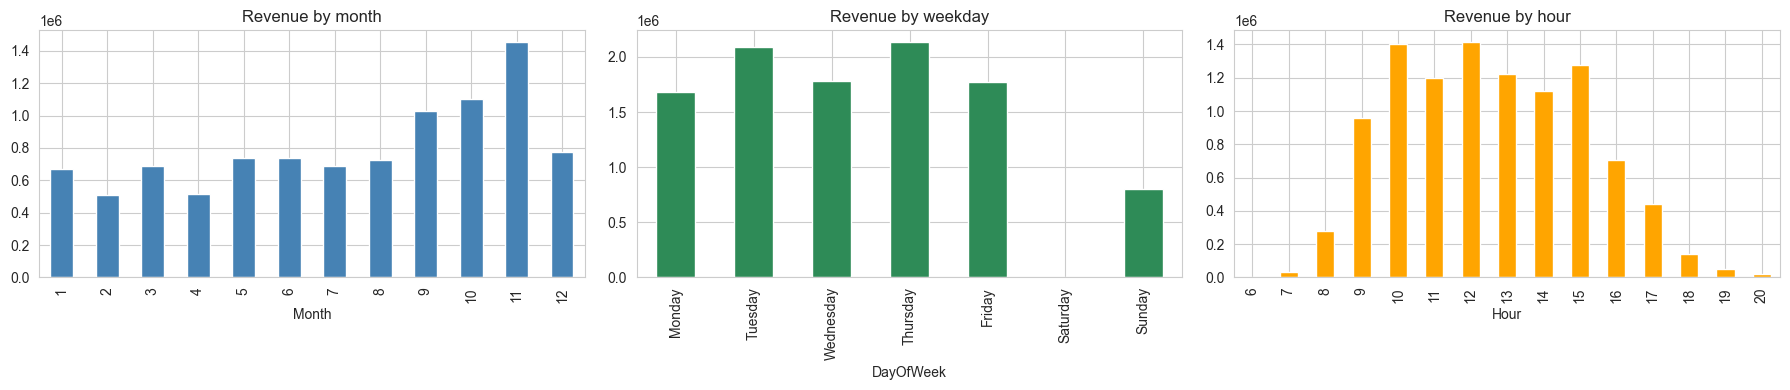

Strongest month number: 11
Strongest weekday: Thursday
Strongest hour: 12


In [24]:
# I leave out Dec 2011 here because it is an incomplete month
full = sales[sales['InvoiceDate'] < '2011-12-01']

month_rev = full.groupby('Month')['TotalLineRevenue'].sum()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_rev = sales.groupby('DayOfWeek')['TotalLineRevenue'].sum().reindex(day_order).fillna(0)
hour_rev = sales.groupby('Hour')['TotalLineRevenue'].sum()

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
month_rev.plot(kind='bar', ax=ax[0], color='steelblue'); ax[0].set_title('Revenue by month')
day_rev.plot(kind='bar', ax=ax[1], color='seagreen'); ax[1].set_title('Revenue by weekday')
hour_rev.plot(kind='bar', ax=ax[2], color='orange'); ax[2].set_title('Revenue by hour')
plt.tight_layout()
plt.show()

peak_month = month_rev.idxmax()
best_day = day_rev.idxmax()
peak_hour = hour_rev.idxmax()
print('Strongest month number:', peak_month)
print('Strongest weekday:', best_day)
print('Strongest hour:', peak_hour)

**Interpretation:**
- Month: November is the strongest, and the last months of the year are clearly above the rest.
- Weekday: sales are spread across the working days. Saturday has no (or almost no) transactions, so the business is mostly a weekday business.
- Hour: sales happen mainly around midday (late morning to mid afternoon). This is the best time to send ads or emails, and a bad time for server maintenance. Night time is the safest window for maintenance.

## Q5. Which countries generate the most customers, orders and revenue?

UK share of revenue: 85.1%


,Customers,Orders,Revenue
Country,,,
United Kingdom,3916,17901,8726309.50
Netherlands,9,93,283889.34
EIRE,3,284,276090.86
Germany,94,443,205381.15
France,87,383,184679.00
Australia,9,56,138103.81
Spain,30,88,55706.56
Switzerland,21,50,53065.60
Japan,8,19,37416.37


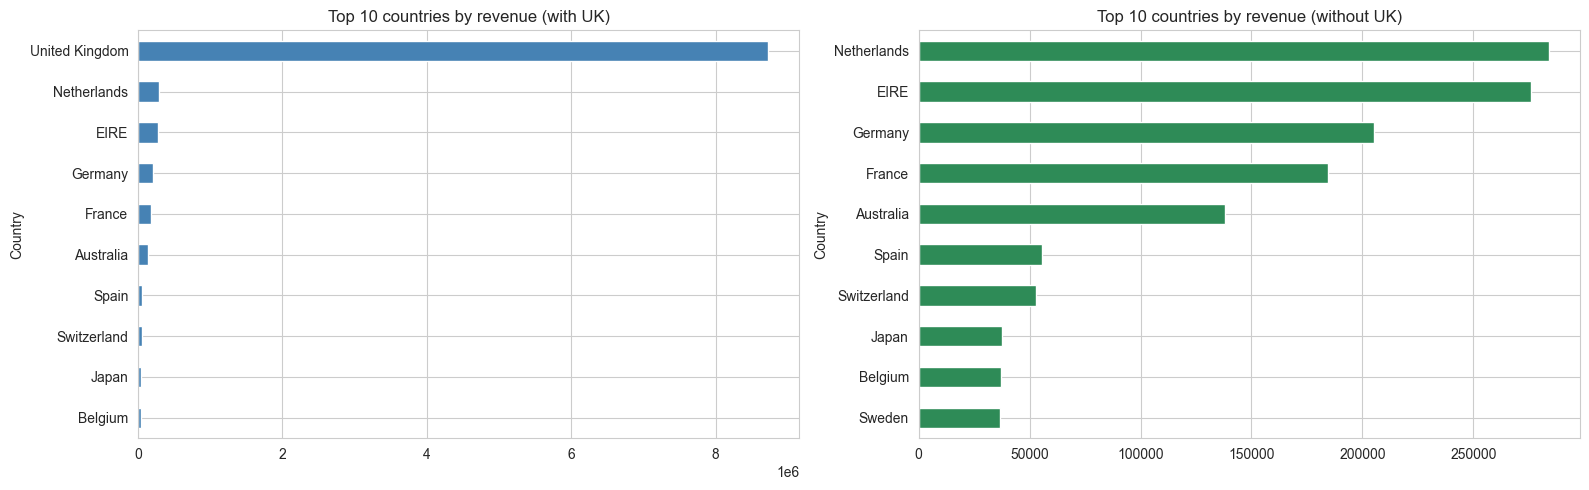

In [25]:
country = sales.groupby('Country').agg(
    Customers=('CustomerID', 'nunique'),
    Orders=('InvoiceNo', 'nunique'),
    Revenue=('TotalLineRevenue', 'sum')).sort_values('Revenue', ascending=False)

uk_share = country.loc['United Kingdom', 'Revenue'] / country['Revenue'].sum() if 'United Kingdom' in country.index else np.nan
print(f'UK share of revenue: {uk_share * 100:.1f}%')
display(country.head(10))

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
country['Revenue'].head(10)[::-1].plot(kind='barh', ax=ax[0], color='steelblue')
ax[0].set_title('Top 10 countries by revenue (with UK)')
country.drop('United Kingdom', errors='ignore')['Revenue'].head(10)[::-1].plot(kind='barh', ax=ax[1], color='seagreen')
ax[1].set_title('Top 10 countries by revenue (without UK)')
plt.tight_layout()
plt.show()

**Interpretation:** The UK is by far the biggest market, so it hides everything else. Once I remove it (right chart), I can see which international markets are worth growing. A few countries have few customers but high revenue, which suggests wholesale buyers.

## Q6. Are there seasonal purchasing patterns?

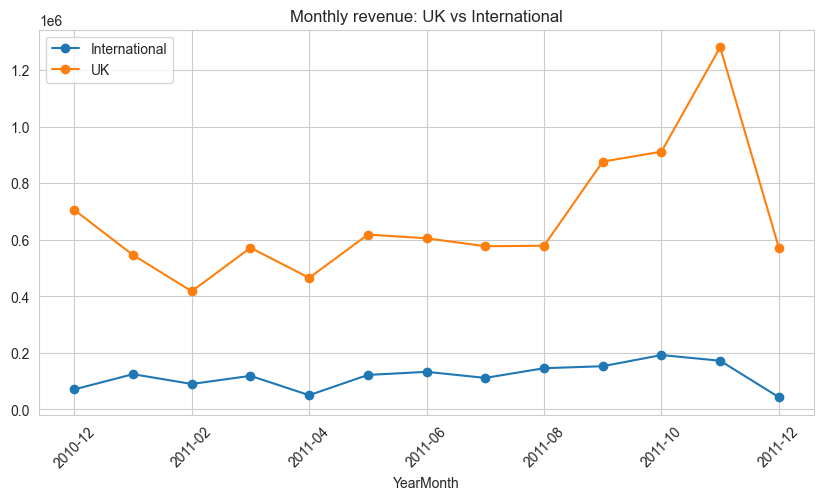

Average revenue Sep-Nov 2011 is 1.81 times the average of Jan-Aug 2011


In [26]:
uk_monthly = sales.groupby(['YearMonth', 'Is_UK'])['TotalLineRevenue'].sum().unstack().fillna(0)
uk_monthly.columns = ['International', 'UK']
uk_monthly.plot(marker='o')
plt.title('Monthly revenue: UK vs International')
plt.xticks(rotation=45)
plt.show()

# average of Jan-Aug 2011 vs Sep-Nov 2011
m = monthly['Gross']
early = m[[i for i in m.index if '2011-01' <= i <= '2011-08']].mean()
late = m[[i for i in m.index if '2011-09' <= i <= '2011-11']].mean()
q4_ratio = late / early
print(f'Average revenue Sep-Nov 2011 is {q4_ratio:.2f} times the average of Jan-Aug 2011')

**Interpretation:** Yes, there is a clear seasonal pattern. Sales rise from September and peak in November, which fits Christmas shopping (retailers and wholesalers stock up before the holiday). The business should prepare stock and marketing before September. I only have one full year, so I cannot say for sure this repeats every year.

## Q7. How common are cancellations and returns, and which products / customers are associated with them?

In [27]:
n_sales_inv = sales['InvoiceNo'].nunique()
n_ret_inv = returns['InvoiceNo'].nunique()
return_value_share = -returns['TotalLineRevenue'].sum() / sales['TotalLineRevenue'].sum()

print('Sales invoices:', n_sales_inv)
print('Cancellation invoices:', n_ret_inv, f'({n_ret_inv / (n_sales_inv + n_ret_inv) * 100:.1f}% of all invoices)')
print(f'Value of returns as % of gross sales: {return_value_share * 100:.1f}%')

ret_prod = returns.groupby('StockCode').agg(Description=('Description', 'first'),
                                            UnitsReturned=('Quantity', lambda x: -x.sum()),
                                            ValueReturned=('TotalLineRevenue', lambda x: -x.sum()))
ret_cust = returns[returns['CustomerID'].notna()].groupby('CustomerID').agg(
    CancelInvoices=('InvoiceNo', 'nunique'), ValueReturned=('TotalLineRevenue', lambda x: -x.sum()))

print('\nTop 10 returned products (by units)')
display(ret_prod.sort_values('UnitsReturned', ascending=False).head(10))
print('Top 10 customers by returned value')
display(ret_cust.sort_values('ValueReturned', ascending=False).head(10))

Sales invoices: 19776
Cancellation invoices: 3422 (14.8% of all invoices)
Value of returns as % of gross sales: 4.6%

Top 10 returned products (by units)


,Description,UnitsReturned,ValueReturned
StockCode,,,
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
23166,MEDIUM CERAMIC TOP STORAGE JAR,74494,77479.64
84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9376,321.60
21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3150,6591.42
85123A,WHITE HANGING HEART T-LIGHT HOLDER,2578,6624.30
21175,GIN + TONIC DIET METAL SIGN,2030,3775.33
22920,HERB MARKER BASIL,1527,841.05
22273,FELTCRAFT DOLL MOLLY,1447,3512.65
47566B,TEA TIME PARTY BUNTING,1424,3692.95


Top 10 customers by returned value


,CancelInvoices,ValueReturned
CustomerID,,
16446,1,168469.60
12346,1,77183.60
15749,1,22998.40
16029,4,12338.16
12931,4,8511.15
14911,44,7443.59
14607,3,5228.40
17450,3,4815.26
17949,5,4814.74


**Interpretation:** Returns are a small share of invoices but can be a bigger share of value, because a few huge cancellations exist. Some of the most returned products are the same as the top unit products from Q1, which means a giant order was probably placed and then cancelled. A few customers are responsible for most of the returned value. The business should look into those customers and products (quality problem, wrong description, or ordering mistakes).

## Q8. What does a typical customer's purchasing behavior look like?

In [28]:
cust[['Orders', 'Revenue', 'Units', 'UniqueProducts', 'AOV']].describe().round(1)

,Orders,Revenue,Units,UniqueProducts,AOV
count,4334.0,4334.0,4334.0,4334.0,4334.0
mean,4.2,2017.5,1186.4,61.4,415.7
std,7.6,8920.4,5041.0,85.3,1800.9
min,1.0,3.8,1.0,1.0,3.8
25%,1.0,304.3,159.2,16.0,177.2
50%,2.0,663.7,377.5,35.0,289.8
75%,5.0,1631.6,989.8,77.0,423.8
max,206.0,279138.0,196844.0,1786.0,84236.2


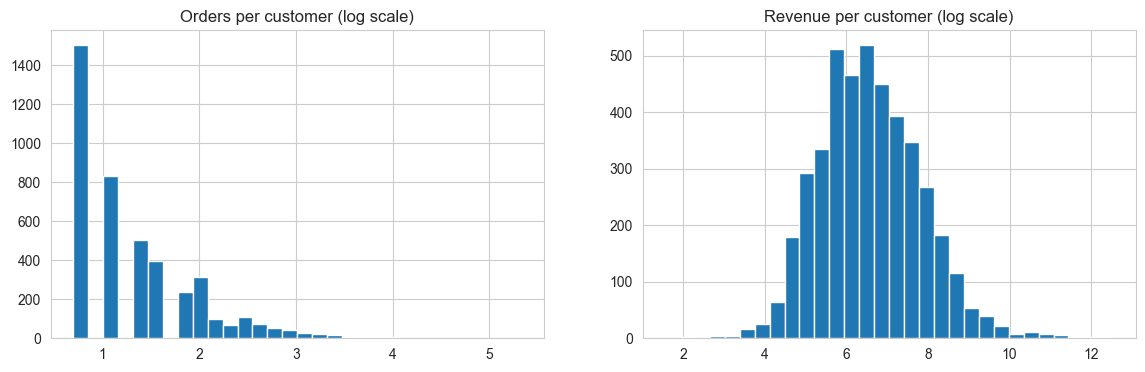

Median orders per customer: 2.0
Median revenue per customer: 663.7
Mean revenue per customer: 2017.5
Customers with only 1 order: 34.7 %


In [29]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
np.log1p(cust['Orders']).hist(bins=30, ax=ax[0]); ax[0].set_title('Orders per customer (log scale)')
np.log1p(cust['Revenue']).hist(bins=30, ax=ax[1]); ax[1].set_title('Revenue per customer (log scale)')
plt.show()

print('Median orders per customer:', cust['Orders'].median())
print('Median revenue per customer:', round(cust['Revenue'].median(), 1))
print('Mean revenue per customer:', round(cust['Revenue'].mean(), 1))
print('Customers with only 1 order:', round((cust['Orders'] == 1).mean() * 100, 1), '%')

**Interpretation:** The mean is much higher than the median, so the distribution is skewed to the right: most customers are small and a few are very big. A typical customer places only a few orders, and many buy just once. This is the reason I use a log transform later.

## Q9. Are there signs of wholesale / bulk-buying behavior?

In [30]:
inv = sales.groupby('InvoiceNo').agg(
    CustomerID=('CustomerID', 'first'),
    Units=('Quantity', 'sum'),
    Lines=('StockCode', 'nunique'),
    AOV=('TotalLineRevenue', 'sum'))

print(inv[['Units', 'Lines', 'AOV']].describe().round(1))

p90 = inv['Units'].quantile(0.9)
big = inv[inv['Units'] >= p90]
big_basket_share_rev = big['AOV'].sum() / inv['AOV'].sum()
print(f'\nThe top 10% biggest baskets (>= {p90:.0f} units) make {big_basket_share_rev * 100:.1f}% of revenue')
print('Median units per line:', sales['Quantity'].median(), '| 90th percentile:', sales['Quantity'].quantile(0.9))

         Units    Lines       AOV
count  19776.0  19776.0   19776.0
mean     281.2     26.2     518.5
std      958.7     47.0    1764.0
min        1.0      1.0       0.4
25%       71.0      6.0     151.8
50%      152.0     15.0     302.3
75%      297.0     29.0     482.5
max    80995.0   1109.0  168469.6

The top 10% biggest baskets (>= 531 units) make 44.5% of revenue
Median units per line: 4.0 | 90th percentile: 24.0


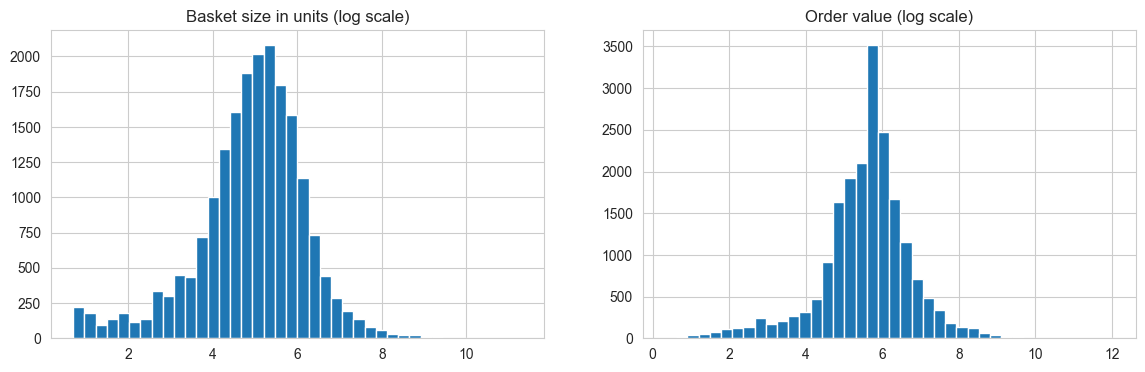

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
np.log1p(inv['Units']).hist(bins=40, ax=ax[0]); ax[0].set_title('Basket size in units (log scale)')
np.log1p(inv['AOV']).hist(bins=40, ax=ax[1]); ax[1].set_title('Order value (log scale)')
plt.show()

**Interpretation:** Yes, there are signs of wholesale buying. Many products are sold in packs of 6, 12 or more, and a small share of the invoices are very large baskets that make a big part of the revenue. So the customer base is a mix: normal small buyers and some bulk buyers. Because this is descriptive data I can only say these customers **look like** wholesalers, I cannot prove it.

## Q10. Can customers be grouped into actionable segments?

Yes, this is answered in `03_rfm` (RFM scores) and `04_clustering` (K-Means segments).

# Business Insights

In [34]:
guest_row_share = df['IsGuest'].mean()

insights = [
    f"1. About {guest_row_share*100:.1f}% of the lines have no CustomerID (guest checkouts), so they cannot be used for customer segmentation.",
    f"2. The best product by revenue is '{top_prod_rev}', and the best by units is '{top_prod_units}'. They are not the same, so units alone can mislead.",
    f"3. {pareto_pct:.1f}% of the products make 80% of revenue, so sales are concentrated in a part of the catalogue.",
    f"4. The top 10% of customers make {top10pct_share*100:.1f}% of the revenue from known customers.",
    f"5. The UK makes {uk_share*100:.1f}% of revenue, so the business depends heavily on one market.",
    f"6. Sep-Nov revenue in 2011 is {q4_ratio:.2f} times the average of Jan-Aug, which shows a strong Q4 season.",
    f"7. The strongest weekday is {best_day} and the strongest hour is {peak_hour}:00.",
    f"8. Returns are worth {return_value_share*100:.1f}% of gross sales value.",
    f"9. The top 10% biggest baskets make {big_basket_share_rev*100:.1f}% of revenue, which points to bulk buyers.",
    f"10. The median customer has {cust['Orders'].median():.0f} orders and {cust['Revenue'].median():.0f} in revenue, but the mean revenue is {cust['Revenue'].mean():.0f}. A few big customers pull the mean up.",
    f"11. {dead_count} high volume products had no net sales in the last 90 days (possible dead stock).",
]
for i in insights:
    print(i)

1. About 25.2% of the lines have no CustomerID (guest checkouts), so they cannot be used for customer segmentation.
2. The best product by revenue is 'REGENCY CAKESTAND 3 TIER', and the best by units is 'PAPER CRAFT , LITTLE BIRDIE'. They are not the same, so units alone can mislead.
3. 21.1% of the products make 80% of revenue, so sales are concentrated in a part of the catalogue.
4. The top 10% of customers make 61.4% of the revenue from known customers.
5. The UK makes 85.1% of revenue, so the business depends heavily on one market.
6. Sep-Nov revenue in 2011 is 1.81 times the average of Jan-Aug, which shows a strong Q4 season.
7. The strongest weekday is Thursday and the strongest hour is 12:00.
8. Returns are worth 4.6% of gross sales value.
9. The top 10% biggest baskets make 44.5% of revenue, which points to bulk buyers.
10. The median customer has 2 orders and 664 in revenue, but the mean revenue is 2018. A few big customers pull the mean up.
11. 21 high volume products had no 